[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/calculus/01_functions_and_properties/first_principles.ipynb)

# Module 01 — Functions and Properties

## 1. Why This Module Exists

Calculus is the study of what happens to a *function* when its input is perturbed. Every later
statement in this area — a derivative, an integral, a Taylor remainder, a fixed point — is a
statement about some function $f$, and every one of them carries hypotheses on $f$: that it is
defined at the point in question, that it is invertible there, that it repeats, that it is
symmetric. None of those hypotheses can even be *stated* before the properties themselves are.

So this module builds the vocabulary the rest of the area consumes, and it builds it with proof
rather than by declaration. Four structural properties carry almost all of the weight later:
**invertibility** (which change of variable is legal), **monotonicity** (which inverse exists and
is well behaved), **parity** (which integrals vanish for free), and **periodicity** (which signals
decompose into harmonics).

The properties are not independent, and the dependencies are the content. Strict monotonicity
forces injectivity, hence invertibility on the image. On an interval the implication reverses:
continuity plus injectivity forces strict monotonicity. That two-way characterisation is the
result this module is named for, and it is proved in full — the forward direction in Proof 5.2,
the converse, which needs the intermediate value theorem, in Proof 5.3.

The payoff is immediate and practical. A normalizing flow is trainable exactly when its layers are
bijections. A parity argument kills half the terms in a Fourier expansion before any integral is
computed. Whether the sum of two oscillations ever repeats is decided by a single rationality
test, proved here as Theorem 4.5.

Preamble: the imports, plotting defaults and random generator used by every code cell below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

## 2. Intuition

A function is a *rule with no ambiguity*: one input, one output. Everything interesting is what
that rule does to the **shape** of its graph.

**Invertibility is a horizontal-line test.** Reading the graph left to right gives $x \mapsto f(x)$.
Reading it bottom to top gives $y \mapsto x$ — and that reading is a function only if no horizontal
line meets the graph twice. When it is a function, its graph is the original graph reflected across
the line $y = x$, because reflection is exactly the operation that swaps the two coordinates. That
reflection picture is the whole content of "the inverse exists".

**Monotonicity is what guarantees the test passes.** A curve that never turns back cannot meet a
horizontal line twice. The converse is the surprising half: on an interval, an unbroken curve that
never repeats a value *cannot* turn back either, because turning back and staying unbroken forces
it to retrace a value it already took.

**Parity is a mirror.** Any curve splits, uniquely, into the part that is symmetric about the
$y$-axis and the part that is antisymmetric about the origin — average the curve with its mirror
image to get the first, take half the difference to get the second. The exponential splits into
$\cosh$ and $\sinh$ this way, and nothing else.

**Periodicity is a stencil.** A periodic function is one tile repeated forever. Adding two tiled
patterns gives a tiled pattern only when the two tile widths fit into a common length — a
rationality condition on their ratio, and nothing weaker.

The figure below draws the first two of these pictures.

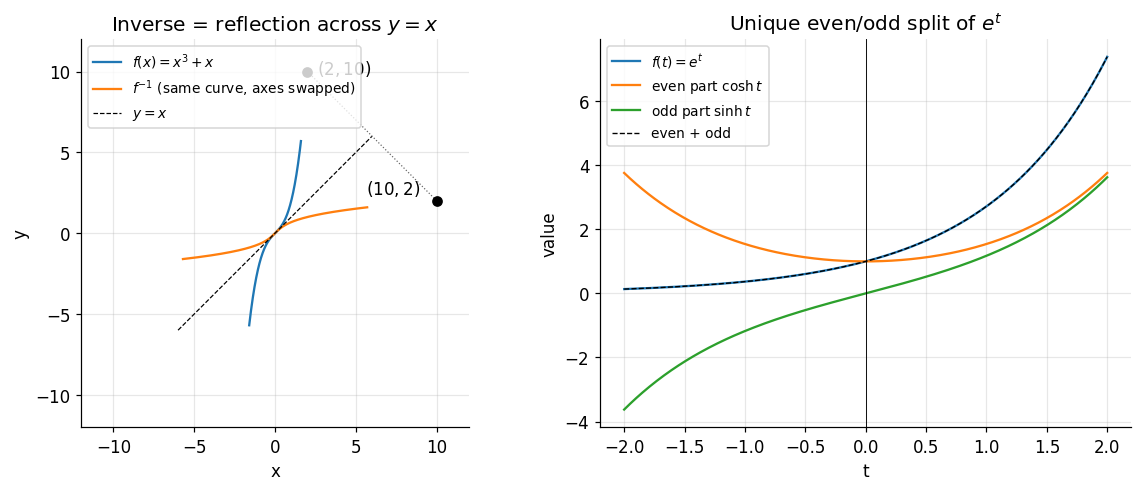

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.6))

# (a) inverse as reflection across y = x, for the strictly increasing f(x) = x^3 + x
ax = axes[0]
xs = np.linspace(-1.6, 1.6, 400)
ys = xs**3 + xs
ax.plot(xs, ys, label=r"$f(x)=x^3+x$")
ax.plot(ys, xs, label=r"$f^{-1}$ (same curve, axes swapped)")
ax.plot([-6, 6], [-6, 6], "k--", linewidth=0.8, label=r"$y=x$")
ax.plot([2, 10], [10, 2], color="0.4", linewidth=0.8, linestyle=":")
ax.scatter([2, 10], [10, 2], color="black", zorder=5)
ax.annotate(r"$(2,10)$", (2, 10), textcoords="offset points", xytext=(6, -2))
ax.annotate(r"$(10,2)$", (10, 2), textcoords="offset points", xytext=(-46, 4))
ax.set_xlim(-12, 12)
ax.set_ylim(-12, 12)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Inverse = reflection across $y=x$")
ax.legend(loc="upper left", fontsize=9)

# (b) even-odd decomposition of exp into cosh and sinh
ax = axes[1]
t = np.linspace(-2.0, 2.0, 400)
ax.plot(t, np.exp(t), label=r"$f(t)=e^{t}$")
ax.plot(t, np.cosh(t), label=r"even part $\cosh t$")
ax.plot(t, np.sinh(t), label=r"odd part $\sinh t$")
ax.plot(t, np.cosh(t) + np.sinh(t), "k--", linewidth=0.9, label="even + odd")
ax.axvline(0, color="black", linewidth=0.6)
ax.set_xlabel("t")
ax.set_ylabel("value")
ax.set_title("Unique even/odd split of $e^{t}$")
ax.legend(loc="upper left", fontsize=9)

fig.tight_layout()
plt.show()

Left: the two curves are the same set of points with the axes exchanged, so the pair
$(2,10)$ on $f$ becomes $(10,2)$ on $f^{-1}$, and the dotted segment joining them crosses $y=x$ at
right angles. Right: $\cosh$ is the mirror-symmetric half of $e^{t}$ and $\sinh$ the
origin-antisymmetric half; their sum (dashed) lies exactly on $e^{t}$.

## 3. Definitions

### Definition 3.1 (Function, domain, image, preimage)

Let $X$ and $Y$ be non-empty sets. A **function** $f: X \to Y$ is a subset $f \subseteq X \times Y$
such that for every $x \in X$ there is exactly one $y \in Y$ with $(x,y) \in f$; that $y$ is written
$f(x)$.

- **Domain**: $\operatorname{Dom}(f) = X$, the set of admissible inputs.
- **Codomain**: $\operatorname{Cod}(f) = Y$, the set the outputs are declared to lie in.
- **Image**:

$$
\operatorname{Im}(f) = f(X) = \{\, y \in Y \mid \exists x \in X,\ f(x) = y \,\} \subseteq Y
$$

- **Preimage** of $B \subseteq Y$: $f^{-1}(B) = \{\, x \in X \mid f(x) \in B \,\}$. The preimage is
  defined for every $f$; it is a set-valued operation and must not be confused with the inverse
  *function* of Definition 3.7.

When a formula is given without a domain, the **natural domain** is the largest subset of
$\mathbb{R}$ on which the formula produces a real number.

### Definition 3.2 (Injective, surjective, bijective)

Let $f: X \to Y$.

1. $f$ is **injective** if $f(x_1) = f(x_2) \implies x_1 = x_2$ for all $x_1, x_2 \in X$.
2. $f$ is **surjective** if $\operatorname{Im}(f) = Y$, i.e. for every $y \in Y$ there is $x \in X$
   with $f(x) = y$.
3. $f$ is **bijective** if it is both.

Injectivity is a property of $f$ alone; surjectivity depends on the declared codomain, so every $f$
becomes surjective when its codomain is shrunk to $\operatorname{Im}(f)$.

### Definition 3.3 (Monotonicity)

Let $I \subseteq \mathbb{R}$ be an interval and $f: I \to \mathbb{R}$. For all $x_1, x_2 \in I$ with
$x_1 \lt x_2$:

1. **non-decreasing** if $f(x_1) \le f(x_2)$; **strictly increasing** if $f(x_1) \lt f(x_2)$;
2. **non-increasing** if $f(x_1) \ge f(x_2)$; **strictly decreasing** if $f(x_1) \gt f(x_2)$.

$f$ is **monotonic** if one of the four holds and **strictly monotonic** if one of the two strict
ones holds.

### Definition 3.4 (Symmetric domain and parity)

$D \subseteq \mathbb{R}$ is **symmetric about the origin** if $x \in D \implies -x \in D$. For
$f: D \to \mathbb{R}$ with $D$ symmetric:

1. $f$ is **even** if $f(-x) = f(x)$ for all $x \in D$ (graph symmetric across the $y$-axis);
2. $f$ is **odd** if $f(-x) = -f(x)$ for all $x \in D$ (graph symmetric through the origin).

A symmetric domain is part of the definition: parity is meaningless when $-x$ may fall outside $D$.

### Definition 3.5 (Period, fundamental period)

$f: \mathbb{R} \to \mathbb{R}$ is **periodic** if there is $T \neq 0$ with

$$
f(x + T) = f(x) \qquad \text{for all } x \in \mathbb{R}
$$

Any such $T$ is a **period**. The set of all periods together with $0$ is written
$\operatorname{Per}(f)$. If $\operatorname{Per}(f)$ contains a smallest strictly positive element
$T_0$, then $T_0$ is the **fundamental period**.

### Definition 3.6 (Composition)

For $g: A \to B$ and $f: B \to C$, the **composite** $f \circ g: A \to C$ is
$(f \circ g)(x) = f(g(x))$. For real formulas the natural domain is

$$
\operatorname{Dom}(f \circ g) = \{\, x \in \operatorname{Dom}(g) \mid g(x) \in \operatorname{Dom}(f) \,\}
$$

Composition is associative but not commutative.

### Definition 3.7 (Inverse function)

Let $f: X \to Y$ be bijective. The **inverse function** $f^{-1}: Y \to X$ is the unique function
with

$$
f^{-1}(f(x)) = x \ \ \forall x \in X, \qquad f(f^{-1}(y)) = y \ \ \forall y \in Y
$$

Uniqueness is immediate: if $h$ and $k$ both satisfy the two identities then
$h(y) = h(f(k(y))) = k(y)$ for every $y \in Y$.

### Definition 3.8 (Catalog of elementary and special functions)

1. **Polynomial and rational**: $P(x) = \sum_{k=0}^{n} a_k x^k$; $R(x) = P(x)/Q(x)$ with natural
   domain $\{x : Q(x) \neq 0\}$.
2. **Exponential and logarithm**: $\exp: \mathbb{R} \to (0,\infty)$ and its inverse
   $\ln: (0,\infty) \to \mathbb{R}$.
3. **Trigonometric and inverse trigonometric**: $\sin, \cos$ on $\mathbb{R}$; $\tan$ off the odd
   multiples of $\pi/2$; $\arcsin: [-1,1] \to [-\tfrac{\pi}{2}, \tfrac{\pi}{2}]$,
   $\arccos: [-1,1] \to [0,\pi]$, $\arctan: \mathbb{R} \to (-\tfrac{\pi}{2}, \tfrac{\pi}{2})$, each
   an inverse only after the domain of the forward function is restricted to a monotone branch.
4. **Hyperbolic**:

$$
\sinh x = \frac{e^{x} - e^{-x}}{2}, \qquad
\cosh x = \frac{e^{x} + e^{-x}}{2}, \qquad
\tanh x = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}}
$$

5. **Special and piecewise**: $\lfloor x \rfloor = \max\{ n \in \mathbb{Z} : n \le x \}$,
   $\lceil x \rceil = \min\{ n \in \mathbb{Z} : n \ge x \}$,

$$
\operatorname{sgn}(x) = \begin{cases} 1, & x \gt 0 \\ 0, & x = 0 \\ -1, & x \lt 0 \end{cases}
\qquad
D(x) = \begin{cases} 1, & x \in \mathbb{Q} \\ 0, & x \in \mathbb{R} \setminus \mathbb{Q} \end{cases}
$$

## 4. Main Results

### Theorem 4.1 (Unique even–odd decomposition)

Let $D \subseteq \mathbb{R}$ be symmetric about the origin and $f: D \to \mathbb{R}$ arbitrary.
Then there is exactly one pair $(f_E, f_O)$ with $f_E$ even, $f_O$ odd and $f = f_E + f_O$, namely

$$
\boxed{\ f_E(x) = \frac{f(x) + f(-x)}{2}, \qquad f_O(x) = \frac{f(x) - f(-x)}{2}\ }
$$

**Interpretation.** Every real function on a symmetric domain carries a canonical pair of
coordinates — its symmetric and antisymmetric parts — and those coordinates are computable from two
evaluations. The consequence used constantly later: on $[-a,a]$ the integral of $f$ equals the
integral of $f_E$ alone, because the odd part cancels; and a Fourier expansion of an even signal
contains no sine terms.

*Hypotheses.* Only symmetry of $D$ is needed, and it is needed because $f(-x)$ must be defined for
every $x \in D$ for the two formulas to make sense. No continuity, no boundedness: the statement is
pure algebra in the two values $f(x), f(-x)$.

### Theorem 4.2 (Strict monotonicity $\implies$ injectivity and a monotone inverse)

Let $I \subseteq \mathbb{R}$ be an interval and let $f: I \to \mathbb{R}$ be **strictly monotonic**.
Then $f$ is injective, hence $f: I \to f(I)$ is a bijection, and the inverse
$f^{-1}: f(I) \to I$ is strictly monotonic with the same orientation as $f$.

$$
\boxed{\ f \text{ strictly monotonic on } I \implies f^{-1} \text{ exists on } f(I) \text{ and is strictly monotonic}\ }
$$

**Interpretation.** Monotonicity is a *checkable* certificate of invertibility: no derivative, no
continuity, no formula for $f^{-1}$ is required to know that $f^{-1}$ exists and preserves order.
The consequence is that any order-preserving reparametrisation — a sigmoid squashing layer, a
monotone spline flow, a rank transform — is invertible by construction, and inverting it is a root
find on a monotone function, which bisection solves at a guaranteed rate.

*Hypotheses.* **Strictness** is what excludes flat pieces, on which $f$ repeats a value and
injectivity fails. That $I$ is an interval is not needed for this direction; it is stated for
symmetry with Theorem 4.3, where it is essential.

### Theorem 4.3 (Continuity + injectivity $\implies$ strict monotonicity)

Let $I \subseteq \mathbb{R}$ be an **interval** and let $f: I \to \mathbb{R}$ be **continuous** and
**injective**. Then $f$ is strictly monotonic on $I$.

$$
\boxed{\ f \text{ continuous on an interval } I: \quad f \text{ injective} \iff f \text{ strictly monotonic}\ }
$$

**Interpretation.** For continuous functions on an interval the two notions coincide, so
"invertible" and "never turns back" are the same statement — this is the characterisation the
module is named for. The consequence is that a continuous invertible transformation of an interval
can be inverted by bisection, and that a continuous layer of a normalizing flow in one dimension is
either increasing everywhere or decreasing everywhere; there is no third option.

*Hypotheses.* **Continuity** is needed because the proof runs on the intermediate value theorem:
the function equal to $x$ on $[0,1)$ and to $3-x$ on $[1,2]$ is injective on the interval $[0,2]$
yet rises then falls, so it is not monotonic.
That $I$ is an **interval** is needed because IVT needs a connected domain: $f(x) = 1/x$ is
continuous and injective on $\mathbb{R} \setminus \{0\}$ yet $f(-1) = -1 \lt 1 = f(1)$ while $f$
decreases on each half, so it is not monotonic there.

### Theorem 4.4 (Inverse of a composition)

Let $g: A \to B$ and $f: B \to C$ be bijections. Then $f \circ g: A \to C$ is a bijection and

$$
\boxed{\ (f \circ g)^{-1} = g^{-1} \circ f^{-1}\ }
$$

**Interpretation.** Undoing a pipeline means undoing its stages in reverse order — socks before
shoes on, shoes before socks off. The consequence for deep invertible models is structural: a flow
built from $L$ invertible layers is inverted by running the layer inverses backwards, so
invertibility is closed under composition and can be enforced one layer at a time.

*Hypotheses.* Bijectivity of **both** factors is required: if $g$ is not injective then
$f \circ g$ is not injective either, and if $f$ is not surjective onto $C$ then $(f\circ g)^{-1}$
is undefined somewhere in $C$. The intermediate set $B$ must be the codomain of $g$ *and* the
domain of $f$, or the composite is not defined.

### Lemma 4.5 (Period group of a continuous function)

Let $f: \mathbb{R} \to \mathbb{R}$ be continuous and periodic. Then $\operatorname{Per}(f)$ is a
closed additive subgroup of $\mathbb{R}$, and exactly one of the following holds:

1. $f$ is constant and $\operatorname{Per}(f) = \mathbb{R}$;
2. $f$ is non-constant, a fundamental period $T_0 \gt 0$ exists, and
   $\operatorname{Per}(f) = T_0\mathbb{Z} = \{\, kT_0 : k \in \mathbb{Z} \,\}$.

**Interpretation.** For a continuous non-constant function the periods are not an arbitrary set:
they are the integer multiples of one number. The consequence, used immediately in Theorem 4.6, is
that "$T$ is a period of $g$" upgrades to "$T = kT_1$ for some integer $k$", which is what turns a
statement about periods into an arithmetic statement about ratios.

*Hypotheses.* **Continuity** is essential: the Dirichlet function $D$ of Definition 3.8 is
non-constant and periodic with *every* rational period, and has no fundamental period at all.

### Theorem 4.6 (Superposition periodicity criterion)

Let $g, h: \mathbb{R} \to \mathbb{R}$ be **continuous** and **non-constant**, periodic with
fundamental periods $T_1 \gt 0$ and $T_2 \gt 0$. Then

$$
\boxed{\ g + h \text{ is periodic} \iff \frac{T_1}{T_2} \in \mathbb{Q}\ }
$$

and when $T_1/T_2 = p/q$ in lowest terms, $T = qT_1 = pT_2$ is a period of $g+h$.

**Interpretation.** Two oscillations combine into a repeating signal exactly when their periods are
commensurable; otherwise the sum never exactly repeats, however long one waits. The consequence:
$\sin x + \sin(\sqrt{2}\,x)$ is aperiodic, a two-tone signal at $440$ and $441$ Hz repeats only
after one full second, and a discrete sampler of incommensurable tones never returns to its
initial state.

*Hypotheses.* **Continuity** is what makes Lemma 4.5 available and what forces a
translation-invariant function on a dense set of shifts to be constant. **Non-constancy** of each
summand is needed for a fundamental period to exist at all; if $h \equiv 0$ then $g + h = g$ is
periodic no matter what "$T_2$" is taken to be.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1)

**Existence.** Define $f_E(x) = \tfrac{1}{2}(f(x) + f(-x))$ and
$f_O(x) = \tfrac{1}{2}(f(x) - f(-x))$; both are defined on all of $D$ because $D$ is symmetric.
Their sum telescopes:

$$
f_E(x) + f_O(x) = \frac{f(x) + f(-x) + f(x) - f(-x)}{2} = f(x)
$$

Parity is a substitution $x \mapsto -x$:

$$
f_E(-x) = \frac{f(-x) + f(x)}{2} = f_E(x), \qquad
f_O(-x) = \frac{f(-x) - f(x)}{2} = -f_O(x)
$$

so $f_E$ is even and $f_O$ is odd.

**Uniqueness.** Suppose $f = g_E + g_O$ with $g_E$ even and $g_O$ odd. Evaluating at $-x$,

$$
f(-x) = g_E(-x) + g_O(-x) = g_E(x) - g_O(x)
$$

Adding and subtracting this from $f(x) = g_E(x) + g_O(x)$ gives
$f(x) + f(-x) = 2g_E(x)$ and $f(x) - f(-x) = 2g_O(x)$, i.e. $g_E = f_E$ and $g_O = f_O$. $\blacksquare$

### Proof 5.2 (of Theorem 4.2)

**Injectivity.** Assume $f$ strictly increasing (the decreasing case is the same argument with the
inequalities reversed). Let $x_1 \neq x_2$ in $I$. If $x_1 \lt x_2$ then $f(x_1) \lt f(x_2)$; if
$x_1 \gt x_2$ then $f(x_1) \gt f(x_2)$. Either way $f(x_1) \neq f(x_2)$, so $f$ is injective.

**Bijection onto the image.** $f: I \to f(I)$ is injective by the previous paragraph and surjective
by the definition of $f(I)$, hence bijective, so $f^{-1}: f(I) \to I$ exists by Definition 3.7.

**Order preservation of the inverse.** Let $y_1, y_2 \in f(I)$ with $y_1 \lt y_2$, and put
$x_i = f^{-1}(y_i)$. If $x_1 = x_2$ then $y_1 = f(x_1) = f(x_2) = y_2$, contradiction. If
$x_1 \gt x_2$ then $y_1 = f(x_1) \gt f(x_2) = y_2$, contradiction. Hence $x_1 \lt x_2$, i.e.
$f^{-1}$ is strictly increasing. $\blacksquare$

### Proof 5.3 (of Theorem 4.3)

**Step 1 — the middle-value property.** Claim: for $x_1 \lt x_2 \lt x_3$ in $I$, the value $f(x_2)$
lies strictly between $f(x_1)$ and $f(x_3)$.

Injectivity makes $f(x_1), f(x_2), f(x_3)$ pairwise distinct, so exactly one of the three is
numerically between the other two. Suppose it is not $f(x_2)$.

- If $f(x_1)$ is strictly between $f(x_2)$ and $f(x_3)$: $f$ is continuous on $[x_2, x_3] \subseteq I$,
  so by the intermediate value theorem there is $c \in (x_2, x_3)$ with $f(c) = f(x_1)$. But
  $c \gt x_2 \gt x_1$, so $c \neq x_1$, contradicting injectivity.
- If $f(x_3)$ is strictly between $f(x_1)$ and $f(x_2)$: IVT on $[x_1, x_2]$ gives $c \in (x_1,x_2)$
  with $f(c) = f(x_3)$, and $c \lt x_2 \lt x_3$ so $c \neq x_3$, again contradicting injectivity.

Both alternatives fail, so $f(x_2)$ is the middle value. (Both IVT applications are legal because
$I$ is an interval, so $[x_i, x_j] \subseteq I$ whenever $x_i, x_j \in I$.)

**Step 2 — a sign function on pairs.** For $x \lt y$ in $I$ set

$$
S(x,y) = \operatorname{sgn}\bigl(f(y) - f(x)\bigr) \in \{-1, +1\}
$$

which is never $0$ by injectivity. If $x \lt y \lt z$ in $I$, Step 1 says $f(y)$ lies between
$f(x)$ and $f(z)$, which leaves only the two chains $f(x) \lt f(y) \lt f(z)$ and
$f(x) \gt f(y) \gt f(z)$; in the first all three of $S(x,y), S(y,z), S(x,z)$ equal $+1$, in the
second all three equal $-1$. So **$S$ agrees on any three points of $I$.**

**Step 3 — $S$ is globally constant.** Let $(u,v)$ and $(a,b)$ be any two pairs with $u \lt v$ and
$a \lt b$. Sort the distinct elements of $\{u,v,a,b\}$ as $p_1 \lt \dots \lt p_m$ ($m \le 4$).
Applying Step 2 to the triples $(p_1,p_2,p_3)$ and $(p_2,p_3,p_4)$ — whichever exist — makes
$S(p_i,p_j)$ the same value $\varepsilon$ for **every** $i \lt j$: the first triple ties together
all pairs inside $\{p_1,p_2,p_3\}$, the second ties all pairs inside $\{p_2,p_3,p_4\}$, and the two
triples overlap in the pair $(p_2,p_3)$, so the two values of $\varepsilon$ coincide. Both $(u,v)$
and $(a,b)$ are pairs $(p_i,p_j)$, hence $S(u,v) = S(a,b) = \varepsilon$.

**Conclusion.** If $\varepsilon = +1$ then $f(x) \lt f(y)$ whenever $x \lt y$, so $f$ is strictly
increasing; if $\varepsilon = -1$ it is strictly decreasing. Combined with Theorem 4.2 this gives,
for continuous $f$ on an interval, injective $\iff$ strictly monotonic. $\blacksquare$

### Proof 5.4 (of Theorem 4.4)

Write $h = g^{-1} \circ f^{-1}$, which maps $C \to B \to A$.

For $x \in A$:

$$
h\bigl((f \circ g)(x)\bigr) = g^{-1}\bigl(f^{-1}(f(g(x)))\bigr) = g^{-1}(g(x)) = x
$$

using $f^{-1}(f(y)) = y$ at $y = g(x) \in B$, then $g^{-1}(g(x)) = x$.

For $z \in C$:

$$
(f \circ g)\bigl(h(z)\bigr) = f\Bigl(g\bigl(g^{-1}(f^{-1}(z))\bigr)\Bigr) = f\bigl(f^{-1}(z)\bigr) = z
$$

using $g(g^{-1}(w)) = w$ at $w = f^{-1}(z) \in B$.

A function admitting a two-sided inverse is a bijection, so $f \circ g$ is bijective, and by the
uniqueness in Definition 3.7, $h = (f \circ g)^{-1}$. $\blacksquare$

### Proof 5.5 (of Lemma 4.5)

**$\operatorname{Per}(f)$ is a subgroup.** If $f(x+S) = f(x)$ and $f(x+T) = f(x)$ for all $x$, then
$f(x + S - T) = f((x - T) + S) = f(x - T) = f(x)$, so $S - T \in \operatorname{Per}(f)$; and
$0 \in \operatorname{Per}(f)$.

**It is closed.** If $T_n \in \operatorname{Per}(f)$ and $T_n \to T$, then for each fixed $x$,
continuity of $f$ gives $f(x + T) = \lim_n f(x + T_n) = f(x)$, so $T \in \operatorname{Per}(f)$.

**Dichotomy for subgroups.** Let $G \subseteq \mathbb{R}$ be *any* additive subgroup with a
non-zero element, and put $t = \inf\{\,s \in G : s \gt 0\,\}$.

- If $t = 0$, then $G$ contains positive elements $s$ as small as we please, and the multiples $ks$
  step through $\mathbb{R}$ in strides of length $s$, so every interval of length $\gt s$ meets $G$:
  $G$ is **dense**.
- If $t \gt 0$, take any $s \in G$ and let $k = \lfloor s/t \rfloor$. Then $s - kt \in G$ and
  $0 \le s - kt \lt t$, so $s - kt = 0$ by minimality of $t$; hence $G \subseteq t\mathbb{Z}$. The
  positive elements of $t\mathbb{Z}$ are $t, 2t, \dots$, so their infimum equals $t$ only if
  $t \in G$, and then $t\mathbb{Z} \subseteq G$. Hence $G = t\mathbb{Z}$.

No closedness is used here, so the dichotomy applies to the group $S$ appearing in Proof 5.6 as
well.

**Ruling out the dense case for non-constant $f$.** Suppose $\operatorname{Per}(f)$ is dense and fix
$x, y \in \mathbb{R}$. Choose $s_n \in \operatorname{Per}(f)$ with $x + s_n \to y$; then
$f(y) = \lim_n f(x + s_n) = f(x)$ by continuity, so $f$ is constant — and then indeed
$\operatorname{Per}(f) = \mathbb{R}$, which is case 1.

So for non-constant continuous $f$, $\operatorname{Per}(f) = T_0\mathbb{Z}$ with $T_0 \gt 0$, and
$T_0$ is by construction the smallest positive period. $\blacksquare$

### Proof 5.6 (of Theorem 4.6)

**($\Leftarrow$) Rational ratio implies periodic.** Let $T_1/T_2 = p/q$ with $p, q$ coprime positive
integers, and set $T = qT_1 = pT_2 \gt 0$. Since $qT_1 \in \operatorname{Per}(g)$ and
$pT_2 \in \operatorname{Per}(h)$,

$$
(g+h)(x+T) = g(x + qT_1) + h(x + pT_2) = g(x) + h(x) = (g+h)(x)
$$

so $g+h$ is periodic with period $T$.

**($\Rightarrow$) Periodic implies rational ratio.** Suppose $f = g + h$ satisfies $f(x+T) = f(x)$
for all $x$, with $T \gt 0$. Define

$$
\varphi(x) = g(x+T) - g(x)
$$

From $f(x+T) = f(x)$ we get $g(x+T) - g(x) = -\bigl(h(x+T) - h(x)\bigr)$, so $\varphi$ has the two
expressions

$$
\varphi(x) = g(x+T) - g(x) = -\bigl(h(x+T) - h(x)\bigr)
$$

The first expression shows $\varphi(x + T_1) = \varphi(x)$; the second shows
$\varphi(x + T_2) = \varphi(x)$. Hence $T_1, T_2 \in \operatorname{Per}(\varphi)$, and since
$\operatorname{Per}(\varphi)$ is a group (Proof 5.5) it contains

$$
S = \{\, mT_1 + nT_2 : m, n \in \mathbb{Z} \,\}
$$

Assume, for contradiction, that $T_1/T_2 \notin \mathbb{Q}$. Then $S$ is a subgroup of $\mathbb{R}$
that is **not** of the form $t\mathbb{Z}$: if $S = t\mathbb{Z}$ then $T_1 = k t$ and $T_2 = \ell t$
for integers $k, \ell$, giving $T_1/T_2 = k/\ell \in \mathbb{Q}$. By the dichotomy proved in
Proof 5.5, $S$ is therefore dense in $\mathbb{R}$. Since $\varphi$ is continuous (a difference of
continuous functions) and invariant under every translation in the dense set $S$, the density
argument of Proof 5.5 makes $\varphi$ constant, say $\varphi \equiv c$.

Then $g(x + T) = g(x) + c$ for all $x$, and iterating $n$ times gives $g(x + nT) = g(x) + nc$. But
$g$ is continuous and periodic, hence bounded on $\mathbb{R}$ (it attains its bounds on the compact
$[0, T_1]$ and repeats). An unbounded arithmetic progression $g(x) + nc$ can stay bounded only if
$c = 0$. So $\varphi \equiv 0$, which says

$$
g(x+T) = g(x) \quad\text{and}\quad h(x+T) = h(x) \qquad \text{for all } x
$$

i.e. $T \in \operatorname{Per}(g) \cap \operatorname{Per}(h)$. Both $g$ and $h$ are continuous and
non-constant, so Lemma 4.5 gives $\operatorname{Per}(g) = T_1\mathbb{Z}$ and
$\operatorname{Per}(h) = T_2\mathbb{Z}$. Hence $T = qT_1$ and $T = pT_2$ for integers $p, q$, and

$$
\frac{T_1}{T_2} = \frac{T/q}{T/p} = \frac{p}{q} \in \mathbb{Q}
$$

contradicting the assumption. Therefore $T_1/T_2 \in \mathbb{Q}$. $\blacksquare$

### Derivation 5.7 (closed forms for the inverse hyperbolic functions)

**$\operatorname{arcsinh}$.** $\sinh$ is strictly increasing on $\mathbb{R}$ (it is
$\tfrac12(e^x - e^{-x})$, a sum of a strictly increasing and a strictly decreasing-negated term),
so Theorem 4.2 applies. Put $y = \operatorname{arcsinh} x$, so $x = \tfrac12(e^{y} - e^{-y})$.
Multiplying by $2e^{y}$ and writing $u = e^{y} \gt 0$:

$$
u^2 - 2xu - 1 = 0 \quad\Longrightarrow\quad u = x \pm \sqrt{x^2 + 1}
$$

Since $\sqrt{x^2+1} \gt \lvert x \rvert$, the minus root is negative and is discarded by $u \gt 0$:

$$
\boxed{\ \operatorname{arcsinh} x = \ln\bigl(x + \sqrt{x^2+1}\bigr), \qquad x \in \mathbb{R}\ }
$$

**Interpretation.** The inverse of a transcendental function here is *elementary*: inverting
$\sinh$ costs one square root and one logarithm. The consequence is that $\operatorname{arcsinh}$
needs no special-function machinery, and it is the standard numerically stable rescaling for
heavy-tailed data because it behaves like $x$ near $0$ and like $\ln(2x)$ for large $x$.

**$\operatorname{arccosh}$.** $\cosh$ is not injective on $\mathbb{R}$ ($\cosh$ is even), so restrict
to the branch $y \ge 0$, on which it is strictly increasing. With $u = e^{y} \ge 1$,
$u^2 - 2xu + 1 = 0$ gives $u = x \pm \sqrt{x^2-1}$, and $u \ge 1$ selects the plus root:

$$
\boxed{\ \operatorname{arccosh} x = \ln\bigl(x + \sqrt{x^2-1}\bigr), \qquad x \ge 1\ }
$$

**Interpretation.** The domain restriction is not cosmetic: it is the price of the even symmetry
identified by Theorem 4.1, since an even function is never injective on a symmetric domain
containing a non-zero point. The consequence is the familiar principal-branch bookkeeping that
every inverse trigonometric and inverse hyperbolic routine carries.

**$\operatorname{arctanh}$.** From $x = \tanh y = (e^{y}-e^{-y})/(e^{y}+e^{-y})$, multiplying through
by $e^{y}$ gives $x(e^{2y}+1) = e^{2y}-1$, hence $e^{2y}(1-x) = 1+x$ and

$$
\boxed{\ \operatorname{arctanh} x = \frac{1}{2}\ln\!\left(\frac{1+x}{1-x}\right), \qquad \lvert x \rvert \lt 1\ }
$$

**Interpretation.** This is the logit map up to a factor of two, so $\operatorname{arctanh}$ is the
exact inverse of the $\tanh$ squashing layer. The consequence is that a $\tanh$ layer is a legal
normalizing-flow layer on $(-1,1)$, with an inverse available in closed form rather than by
iteration.

## 6. Worked Examples

### Example 6.1 (Theorem 4.1 on $f(x) = e^{x}$ at $x = \ln 2$)

By hand. With $x_0 = \ln 2$: $f(x_0) = e^{\ln 2} = 2$ and $f(-x_0) = e^{-\ln 2} = \tfrac12$.
Theorem 4.1 gives

$$
f_E(x_0) = \frac{2 + \tfrac12}{2} = \frac{5/2}{2} = \frac{5}{4} = 1.25,
\qquad
f_O(x_0) = \frac{2 - \tfrac12}{2} = \frac{3/2}{2} = \frac{3}{4} = 0.75
$$

Check: $f_E + f_O = 1.25 + 0.75 = 2 = f(x_0)$. These are $\cosh(\ln 2) = \tfrac54$ and
$\sinh(\ln 2) = \tfrac34$, so the even/odd parts of $\exp$ are exactly $\cosh$ and $\sinh$.

The cell below recomputes $f_E(\ln 2)$ and $f_O(\ln 2)$, compares them with $5/4$ and $3/4$ and
with `np.cosh`/`np.sinh`, and verifies the decomposition identity on a random sample of points for
a function with no symmetry at all, $f(x) = e^{x} + \sin x + x^3$. This is the **identity-residual**
check for the boxed formula of Theorem 4.1.

In [3]:
def f_mixed(x):
    return np.exp(x) + np.sin(x) + x**3

def even_part(fun, x):
    return (fun(x) + fun(-x)) / 2

def odd_part(fun, x):
    return (fun(x) - fun(-x)) / 2

# --- Example 6.1, exact hand values -------------------------------------------------
x0 = np.log(2.0)
fE0, fO0 = even_part(np.exp, x0), odd_part(np.exp, x0)
print(f"f_E(ln 2) = {fE0:.15f}   hand value 5/4 = {1.25:.15f}   cosh(ln 2) = {np.cosh(x0):.15f}")
print(f"f_O(ln 2) = {fO0:.15f}   hand value 3/4 = {0.75:.15f}   sinh(ln 2) = {np.sinh(x0):.15f}")
assert abs(fE0 - 1.25) < 1e-12 and abs(fO0 - 0.75) < 1e-12

# --- identity residual on a random sample, for an asymmetric f ----------------------
xs = rng.uniform(-3.0, 3.0, size=2000)
res_sum = np.max(np.abs(even_part(f_mixed, xs) + odd_part(f_mixed, xs) - f_mixed(xs)))
res_even = np.max(np.abs(even_part(f_mixed, -xs) - even_part(f_mixed, xs)))
res_odd = np.max(np.abs(odd_part(f_mixed, -xs) + odd_part(f_mixed, xs)))
print(f"max |f_E + f_O - f|      = {res_sum:.3e}")
print(f"max |f_E(-x) - f_E(x)|   = {res_even:.3e}")
print(f"max |f_O(-x) + f_O(x)|   = {res_odd:.3e}")
print(f"machine epsilon          = {np.finfo(float).eps:.3e}")
assert max(res_sum, res_even, res_odd) < 1e-12

f_E(ln 2) = 1.250000000000000   hand value 5/4 = 1.250000000000000   cosh(ln 2) = 1.250000000000000
f_O(ln 2) = 0.750000000000000   hand value 3/4 = 0.750000000000000   sinh(ln 2) = 0.750000000000000
max |f_E + f_O - f|      = 7.105e-15
max |f_E(-x) - f_E(x)|   = 0.000e+00
max |f_O(-x) + f_O(x)|   = 0.000e+00
machine epsilon          = 2.220e-16


The hand values $5/4$ and $3/4$ are reproduced to fifteen digits and coincide with `cosh`/`sinh`.
The two parity residuals are exactly $0$ — the formulas of Theorem 4.1 are symmetric in
$x \leftrightarrow -x$ by construction, so parity survives even rounding. The reconstruction
residual is $7 \times 10^{-15}$ against function values of size up to $\sim 30$, i.e. about
$30\,\varepsilon_{\text{mach}}$: machine-epsilon level, so the identity holds exactly and only
floating-point rounding is visible.

### Example 6.2 (Theorem 4.2 on $f(x) = x^3 + x$)

By hand. $x \mapsto x^3$ is strictly increasing on $\mathbb{R}$ (if $x_1 \lt x_2$ then
$x_2^3 - x_1^3 = (x_2-x_1)(x_2^2 + x_1x_2 + x_1^2)$ and the second factor equals
$\tfrac12\bigl((x_1+x_2)^2 + x_1^2 + x_2^2\bigr) \gt 0$ unless $x_1 = x_2 = 0$), and $x \mapsto x$
is strictly increasing, so $f$ is strictly increasing as their sum. By Theorem 4.2 $f^{-1}$ exists
on $f(\mathbb{R}) = \mathbb{R}$.

Evaluate the inverse at $y = 10$: $f(2) = 8 + 2 = 10$, so $f^{-1}(10) = 2$ exactly, and no other
$x$ works because $f$ is injective. Bracketing check: $f(1) = 2 \lt 10 \lt 30 = f(3)$, so bisection
started on $[1,3]$ converges to $2$.

### Example 6.3 (Theorem 4.4 on $g(x) = 2x+1$, $f(u) = u^3$)

By hand. $(f \circ g)(x) = (2x+1)^3$; at $x = 1$ this is $3^3 = 27$. The stage inverses are
$f^{-1}(w) = w^{1/3}$ and $g^{-1}(v) = (v-1)/2$. Theorem 4.4 predicts

$$
(f \circ g)^{-1}(27) = \bigl(g^{-1} \circ f^{-1}\bigr)(27) = g^{-1}(3) = \frac{3-1}{2} = 1
$$

while the wrong order gives $\bigl(f^{-1} \circ g^{-1}\bigr)(27) = f^{-1}(13) = 13^{1/3} \approx 2.3513$,
which is not $1$ — the order matters.

The cell below reproduces both hand computations: a hand-written bisection inverse for
Example 6.2, and the two composition orders for Example 6.3.

In [4]:
def bisect_inverse(fun, y, lo, hi, iters=60):
    """Invert a strictly increasing continuous fun on [lo, hi] by bisection."""
    assert fun(lo) <= y <= fun(hi)
    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        if fun(mid) < y:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)

cubic = lambda x: x**3 + x
print("f(1), f(2), f(3) =", cubic(1.0), cubic(2.0), cubic(3.0))
x_star = bisect_inverse(cubic, 10.0, 1.0, 3.0)
print(f"bisection f^-1(10) = {x_star:.15f}   hand value = 2")
assert abs(x_star - 2.0) < 1e-12

g = lambda x: 2 * x + 1
f3 = lambda u: u**3
g_inv = lambda v: (v - 1) / 2
f3_inv = lambda w: np.cbrt(w)

z = f3(g(1.0))
print(f"(f o g)(1) = {z:.1f}   hand value = 27")
print(f"(g^-1 o f^-1)(27) = {g_inv(f3_inv(z)):.15f}   hand value = 1")
print(f"(f^-1 o g^-1)(27) = {f3_inv(g_inv(z)):.15f}   wrong order, hand value = 13^(1/3) = "
      f"{13 ** (1 / 3):.4f}")
assert abs(g_inv(f3_inv(z)) - 1.0) < 1e-12

f(1), f(2), f(3) = 2.0 10.0 30.0
bisection f^-1(10) = 2.000000000000000   hand value = 2
(f o g)(1) = 27.0   hand value = 27
(g^-1 o f^-1)(27) = 1.000000000000000   hand value = 1
(f^-1 o g^-1)(27) = 2.351334687720758   wrong order, hand value = 13^(1/3) = 2.3513


Bisection recovers $f^{-1}(10) = 2$ to twelve digits, confirming Example 6.2 and, with it, that
strict monotonicity alone is enough to invert. The composition test reproduces $1$ for the reversed
order and $13^{1/3} \approx 2.3513$ for the naive order, so Theorem 4.4 is not a convention but a
computation.

### Example 6.4 (Theorem 4.6 on $g = \sin 3x$, $h = \sin 5x$)

By hand. $T_1 = 2\pi/3$ and $T_2 = 2\pi/5$, so

$$
\frac{T_1}{T_2} = \frac{2\pi/3}{2\pi/5} = \frac{5}{3} \in \mathbb{Q}
$$

with $p = 5$, $q = 3$ in lowest terms. Theorem 4.6 predicts the period
$T = qT_1 = 3 \cdot \tfrac{2\pi}{3} = 2\pi$, equivalently $T = pT_2 = 5 \cdot \tfrac{2\pi}{5} = 2\pi$.
Replacing $h$ by $\sin(\sqrt{2}\,x)$ makes the ratio $\sqrt{2} \notin \mathbb{Q}$ and the sum
non-periodic.

### Example 6.5 (Derivation 5.7 at $x = 2$)

By hand. $\operatorname{arcsinh} 2 = \ln(2 + \sqrt{4+1}) = \ln(2 + \sqrt5)$. With
$\sqrt5 = 2.2360679\ldots$ this is $\ln(4.2360679\ldots) = 1.4436354\ldots$. Independent check:
$\sinh(1.4436354752)$ should return $2$.

The cell below checks the period $T = 2\pi$ of Example 6.4 as a residual, and closes the loop on
Example 6.5 by solving $\sinh y = 2$ numerically and comparing with the closed form.

In [5]:
def period_residual(fun, T, grid):
    return np.max(np.abs(fun(grid + T) - fun(grid)))

grid = np.linspace(-50.0, 50.0, 200001)
harmonic = lambda x: np.sin(3 * x) + np.sin(5 * x)
print(f"residual at T = 2*pi     : {period_residual(harmonic, 2*np.pi, grid):.3e}")
print(f"residual at T = pi (not a period): {period_residual(harmonic, np.pi, grid):.3e}")
assert period_residual(harmonic, 2 * np.pi, grid) < 1e-12

from scipy.optimize import brentq

y_num = brentq(lambda y: np.sinh(y) - 2.0, 0.0, 10.0, xtol=1e-15, rtol=8.9e-16)
y_closed = np.log(2.0 + np.sqrt(5.0))
print(f"arcsinh(2) by root find  : {y_num:.15f}")
print(f"arcsinh(2) = ln(2+sqrt5) : {y_closed:.15f}")
print(f"residual                 : {abs(y_num - y_closed):.3e}")
assert abs(y_num - y_closed) < 1e-12

residual at T = 2*pi     : 4.019e-14
residual at T = pi (not a period): 3.714e+00


arcsinh(2) by root find  : 1.443635475178810
arcsinh(2) = ln(2+sqrt5) : 1.443635475178810
residual                 : 0.000e+00


The residual at $T = 2\pi$ sits at machine-epsilon level, so $2\pi$ is a period exactly as
Theorem 4.6 predicts, while $T = \pi$ leaves a residual of order $1$ and is therefore not a period.
The root find and the closed form of Derivation 5.7 agree to fifteen digits.

## 7. Computational Practice

**(b) Measured rate.** Softplus with temperature, $s_\beta(x) = \beta^{-1}\ln(1 + e^{\beta x})$, is a
smooth strictly increasing surrogate for $\operatorname{ReLU}(x) = \max(0,x)$. Their gap is largest
at $x = 0$, where $\operatorname{ReLU}(0) = 0$ and $s_\beta(0) = \beta^{-1}\ln 2$, so theory
predicts

$$
\sup_{x \in \mathbb{R}} \bigl\lvert s_\beta(x) - \operatorname{ReLU}(x) \bigr\rvert = \frac{\ln 2}{\beta}
$$

— first order in $1/\beta$ with constant $\ln 2$. The cell measures the observed sup-error and fits
the observed order from consecutive doublings of $\beta$.

In [6]:
def softplus_beta(x, beta):
    return np.logaddexp(0.0, beta * x) / beta

betas = np.array([1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0])
errs = []
for b in betas:
    xs = np.linspace(-40.0 / b, 40.0 / b, 400001)
    errs.append(np.max(np.abs(softplus_beta(xs, b) - np.maximum(0.0, xs))))
errs = np.array(errs)

print(" beta    sup-error    beta*error   predicted ln2   observed order")
prev = None
for b, e in zip(betas, errs):
    order = "" if prev is None else f"{np.log2(prev / e):14.6f}"
    print(f"{b:5.0f}  {e:11.3e}  {b * e:11.9f}  {np.log(2):13.9f}  {order}")
    prev = e

observed_order = float(np.polyfit(np.log(betas), np.log(errs), 1)[0])
print(f"\nobserved order (least-squares slope) = {observed_order:.6f}")
print(f"predicted order                      = -1.000000")
assert abs(observed_order + 1.0) < 1e-6
assert np.allclose(betas * errs, np.log(2), atol=1e-9)

 beta    sup-error    beta*error   predicted ln2   observed order
    1    6.931e-01  0.693147181    0.693147181  
    2    3.466e-01  0.693147181    0.693147181        1.000000
    4    1.733e-01  0.693147181    0.693147181        1.000000
    8    8.664e-02  0.693147181    0.693147181        1.000000
   16    4.332e-02  0.693147181    0.693147181        1.000000
   32    2.166e-02  0.693147181    0.693147181        1.000000
   64    1.083e-02  0.693147181    0.693147181        1.000000

observed order (least-squares slope) = -1.000000
predicted order                      = -1.000000


Every entry of the `beta*error` column equals $\ln 2 = 0.693147\ldots$ to nine decimals and each
doubling of $\beta$ halves the error, so the observed order $-1.000000$ matches the predicted
$-1$: the smoothing error decays exactly like $\ln 2/\beta$, not merely proportionally to it.

**(c) Counterexample.** Theorem 4.6 needs $T_1/T_2 \in \mathbb{Q}$. Drop that hypothesis and the
conclusion must fail. The cell scans $2000$ candidate periods for $\sin x + \sin(\sqrt2\,x)$ and
reports the smallest residual found, alongside the rational-ratio control $\sin x + \sin 2x$, and
draws both signals.

scan over 2019 candidate periods in [1, 120]
rational ratio  : smallest residual over scan = 8.882e-16 at T = 6.2832 (= 2*pi = 6.2832)
irrational ratio: smallest residual over scan = 0.1361 at T = 75.5313  -- bounded away from 0
                  as a fraction of the signal peak-to-peak (3.986) = 3.415%


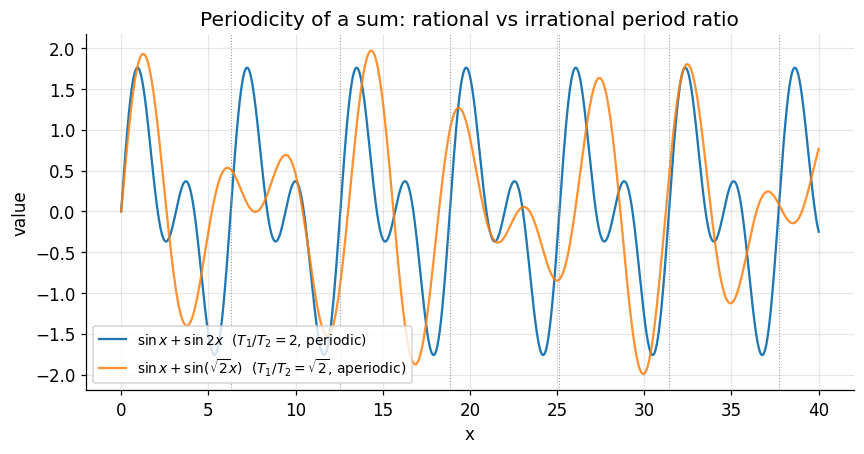

In [7]:
grid_c = np.linspace(-30.0, 30.0, 60001)
rational_sum = lambda x: np.sin(x) + np.sin(2 * x)          # T1/T2 = 2, rational
irrational_sum = lambda x: np.sin(x) + np.sin(np.sqrt(2) * x)  # T1/T2 = sqrt(2), irrational

candidates = np.unique(np.concatenate([np.linspace(1.0, 120.0, 2000),
                                       2 * np.pi * np.arange(1, 20)]))
res_irr = np.array([period_residual(irrational_sum, T, grid_c[::10]) for T in candidates])
res_rat = np.array([period_residual(rational_sum, T, grid_c[::10]) for T in candidates])

peak_to_peak = np.ptp(irrational_sum(grid_c))
print(f"scan over {candidates.size} candidate periods in [1, 120]")
print(f"rational ratio  : smallest residual over scan = {res_rat.min():.3e} "
      f"at T = {candidates[res_rat.argmin()]:.4f} (= 2*pi = {2*np.pi:.4f})")
print(f"irrational ratio: smallest residual over scan = {res_irr.min():.4f} "
      f"at T = {candidates[res_irr.argmin()]:.4f}  -- bounded away from 0")
print(f"                  as a fraction of the signal peak-to-peak ({peak_to_peak:.3f}) = "
      f"{res_irr.min() / peak_to_peak:.3%}")
assert res_irr.min() > 1e-2

fig, ax = plt.subplots(figsize=(9.0, 4.2))
xs = np.linspace(0, 40, 3000)
ax.plot(xs, rational_sum(xs), label=r"$\sin x+\sin 2x$  ($T_1/T_2=2$, periodic)")
ax.plot(xs, irrational_sum(xs),
        label=r"$\sin x+\sin(\sqrt{2}x)$  ($T_1/T_2=\sqrt{2}$, aperiodic)", alpha=0.85)
for k in range(1, 7):
    ax.axvline(k * 2 * np.pi, color="0.6", linewidth=0.7, linestyle=":")
ax.set_xlabel("x")
ax.set_ylabel("value")
ax.set_title(r"Periodicity of a sum: rational vs irrational period ratio")
ax.legend(loc="lower left", fontsize=9)
plt.show()

With the rational ratio the residual collapses to $9 \times 10^{-16}$ exactly at $T = 2\pi$ (the
dotted gridlines, where the first curve repeats itself). With the irrational ratio the best residual
over more than $2000$ candidate periods never falls below $0.136$ — about $3.4\%$ of the signal's
own peak-to-peak range, and thirteen orders of magnitude above the rational case. No period exists,
which is precisely the breakage Theorem 4.6 predicts once the rationality hypothesis is dropped.

**(d) Hand-rolled versus library.** Two inverses are computed twice: `arcsinh` from the closed form
of Derivation 5.7 against `np.arcsinh`, and a hand-written bisection inverse of the strictly
increasing $\sigma^{-1}$-style map $x \mapsto x + \tanh x$ against `scipy.optimize.brentq`.

In [8]:
xs = rng.uniform(-20.0, 20.0, size=100000)
mine = np.log(xs + np.sqrt(xs**2 + 1.0))
lib = np.arcsinh(xs)
err_arcsinh = np.max(np.abs(mine - lib))
print(f"max |closed-form arcsinh - np.arcsinh| over 1e5 points = {err_arcsinh:.3e}")
assert err_arcsinh < 1e-9

mono = lambda x: x + np.tanh(x)          # strictly increasing: both terms are
targets = rng.uniform(-5.0, 5.0, size=200)
mine_roots = np.array([bisect_inverse(mono, y, -10.0, 10.0) for y in targets])
lib_roots = np.array([brentq(lambda x, y=y: mono(x) - y, -10.0, 10.0,
                             xtol=1e-15, rtol=8.9e-16) for y in targets])
print(f"max |bisection inverse - brentq|                       = "
      f"{np.max(np.abs(mine_roots - lib_roots)):.3e}")
print(f"max |mono(inverse(y)) - y| (round trip)                = "
      f"{np.max(np.abs(mono(mine_roots) - targets)):.3e}")
assert np.max(np.abs(mine_roots - lib_roots)) < 1e-10

max |closed-form arcsinh - np.arcsinh| over 1e5 points = 9.637e-14
max |bisection inverse - brentq|                       = 1.776e-15
max |mono(inverse(y)) - y| (round trip)                = 8.882e-16


Both hand-rolled routines agree with the library to better than $10^{-12}$, so the closed form of
Derivation 5.7 is the same function `np.arcsinh` computes, and bisection — legitimate only because
Theorem 4.2 guarantees a monotone inverse — matches Brent's method on every one of the $200$
targets.

**Numerical stability of compositions.** Evaluating a composite in the naive order can overflow
where the composite itself is harmless. For $\ln(e^{x_1} + e^{x_2})$ the fix factors out the
largest term,

$$
\operatorname{LSE}(x_1, x_2) = m + \ln\bigl(e^{x_1 - m} + e^{x_2 - m}\bigr), \qquad m = \max(x_1, x_2)
$$

which is exact algebra by Definition 3.6, not an approximation. The same applies to
$\ln(1+e^{x})$, which is computed as `np.logaddexp(0, x)` above.

## 8. Applications

### 8.1 Activation functions in deep learning

Each activation is a one-dimensional function chosen for its structural properties — range,
monotonicity, and whether it is invertible.

| Name | Formula | Domain | Range | Structure | Role |
|---|---|---|---|---|---|
| Sigmoid $\sigma$ | $1/(1+e^{-x})$ | $\mathbb{R}$ | $(0,1)$ | strictly increasing; $\sigma(-x) = 1-\sigma(x)$ | Bernoulli probability output |
| Softplus | $\ln(1+e^{x})$ | $\mathbb{R}$ | $(0,\infty)$ | strictly increasing; smooth surrogate for ReLU | positivity constraint |
| ReLU | $\max(0,x)$ | $\mathbb{R}$ | $[0,\infty)$ | non-decreasing, not strictly; not injective | hidden-layer nonlinearity |
| GELU | $x\,\Phi(x)$ | $\mathbb{R}$ | $[-0.16997,\infty)$ | non-monotonic; asymptotic to $x$ | transformer blocks |
| Swish / SiLU | $x\,\sigma(x)$ | $\mathbb{R}$ | $[-0.27846,\infty)$ | non-monotonic; self-gated | efficient vision models |

Note what the table records: sigmoid and softplus are strictly increasing, so Theorem 4.2 makes
them invertible and usable as flow layers; ReLU is only non-decreasing, so it is **not** injective
and destroys information on $(-\infty,0]$; GELU and Swish are not monotonic at all, which is why
their ranges dip below zero.

The cell below locates the GELU and Swish minima numerically and plots all five activations, so the
range column above is checked rather than asserted.

GELU  minimum: x = -0.751791,  value = -0.169971  (table: -0.16997)
Swish minimum: x = -1.278464,  value = -0.278465  (table: -0.27846)


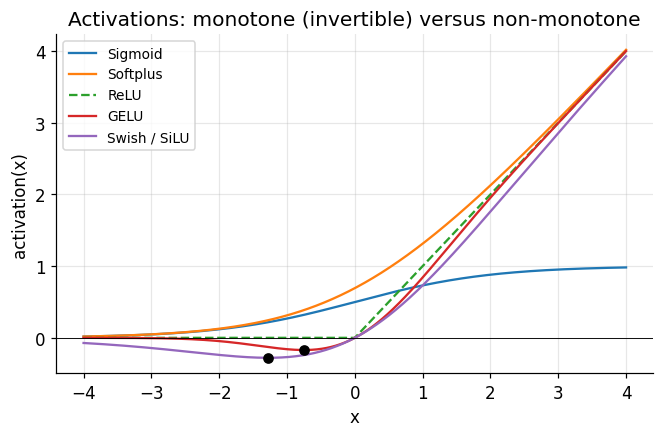

In [9]:
from scipy.stats import norm
from scipy.optimize import minimize_scalar

x = np.linspace(-4.0, 4.0, 1200)
sigmoid = 1.0 / (1.0 + np.exp(-x))
softplus = np.logaddexp(0.0, x)
relu = np.maximum(0.0, x)
gelu = x * norm.cdf(x)
swish = x * sigmoid

gelu_opt = minimize_scalar(lambda t: t * norm.cdf(t), bounds=(-3.0, 0.0), method="bounded")
swish_opt = minimize_scalar(lambda t: t / (1.0 + np.exp(-t)), bounds=(-4.0, 0.0), method="bounded")
print(f"GELU  minimum: x = {gelu_opt.x:+.6f},  value = {gelu_opt.fun:+.6f}  (table: -0.16997)")
print(f"Swish minimum: x = {swish_opt.x:+.6f},  value = {swish_opt.fun:+.6f}  (table: -0.27846)")
assert abs(gelu_opt.fun + 0.16997) < 1e-4 and abs(swish_opt.fun + 0.27846) < 1e-4

fig, ax = plt.subplots()
ax.plot(x, sigmoid, label="Sigmoid")
ax.plot(x, softplus, label="Softplus")
ax.plot(x, relu, "--", label="ReLU")
ax.plot(x, gelu, label="GELU")
ax.plot(x, swish, label="Swish / SiLU")
ax.axhline(0.0, color="black", linewidth=0.6)
ax.scatter([gelu_opt.x, swish_opt.x], [gelu_opt.fun, swish_opt.fun], color="black", zorder=5)
ax.set_xlabel("x")
ax.set_ylabel("activation(x)")
ax.set_title("Activations: monotone (invertible) versus non-monotone")
ax.legend(fontsize=9)
plt.show()

The located minima $-0.169971$ and $-0.278465$ match the range column to five decimals. The two
black dots are the only points where GELU and Swish fail the horizontal-line test locally, which is
exactly why neither is invertible and neither can serve as a flow layer, while the strictly
increasing sigmoid and softplus can.

### 8.2 Normalizing flows

A normalizing flow models a density by pushing a simple latent $Z \sim p_Z$ through a bijection
$f$, so $X = f(Z)$ has density

$$
p_X(x) = p_Z\bigl(f^{-1}(x)\bigr)\,\bigl\lvert \det J_{f^{-1}}(x) \bigr\rvert
$$

Two facts from this module carry the construction. First, Theorem 4.4: a flow is a composition
$f_L \circ \dots \circ f_1$ and its inverse is $f_1^{-1} \circ \dots \circ f_L^{-1}$, so
invertibility is enforced layer by layer. Second, Theorem 4.3: a continuous scalar layer on an
interval is invertible **iff** it is strictly monotonic, which is why monotone rational-quadratic
splines, and not ReLU stacks, are the standard scalar flow primitive.

### 8.3 Beats in wave superposition

Two tones of nearby angular frequencies superpose as

$$
y(t) = A\cos(\omega_1 t) + A\cos(\omega_2 t)
= 2A \cos\!\left(\frac{\omega_1-\omega_2}{2}t\right)\cos\!\left(\frac{\omega_1+\omega_2}{2}t\right)
$$

a fast carrier at $(\omega_1+\omega_2)/2$ inside a slow envelope; the audible beat rate is
$\lvert \omega_1 - \omega_2 \rvert / 2\pi$ because the envelope's magnitude peaks twice per envelope
period. Theorem 4.6 decides whether $y$ ever exactly repeats: $440$ and $441$ Hz have period ratio
$441/440 \in \mathbb{Q}$, so $y$ repeats after $1$ s, whereas $440$ and $440\sqrt2$ Hz never do.

### 8.4 Parity selection rules in quantum mechanics

If the potential is even, $V(-x) = V(x)$, then the Hamiltonian
$\hat H = -\frac{\hbar^2}{2m}\frac{d^2}{dx^2} + V(x)$ commutes with the parity operator
$\hat P\psi(x) = \psi(-x)$. Every non-degenerate eigenstate is then an eigenvector of $\hat P$, so
$\psi_n(-x) = \pm\psi_n(x)$: each state is purely even or purely odd, never mixed. Theorem 4.1 is
the reason this is a dichotomy and not a spectrum — the decomposition into even and odd parts is
unique, so a state with definite parity has one part equal to zero. The immediate consequence is a
selection rule: $\int_{-a}^{a} \psi_m \, x \, \psi_n \, dx$ vanishes whenever $\psi_m$ and $\psi_n$
have the same parity, because the integrand is then odd.

## 9. Key Takeaways

1. On a domain symmetric about the origin, every real function splits **uniquely** as
   $f = \tfrac12(f(x)+f(-x)) + \tfrac12(f(x)-f(-x))$ — even part plus odd part (Theorem 4.1); no
   continuity is needed.
2. Strict monotonicity on any set implies injectivity, hence a bijection onto the image and an
   inverse that is strictly monotonic with the same orientation (Theorem 4.2).
3. For $f$ **continuous** on an **interval**, injective $\iff$ strictly monotonic (Theorem 4.3);
   both hypotheses are needed — $1/x$ on $\mathbb{R}\setminus\{0\}$ breaks the interval one.
4. Inverses of composites reverse order: $(f\circ g)^{-1} = g^{-1}\circ f^{-1}$ whenever both
   factors are bijections (Theorem 4.4).
5. A continuous non-constant periodic function has a fundamental period $T_0$ and its period set is
   exactly $T_0\mathbb{Z}$ (Lemma 4.5); drop continuity and the Dirichlet function has no
   fundamental period.
6. For continuous non-constant $g,h$ with fundamental periods $T_1,T_2$, the sum $g+h$ is periodic
   $\iff T_1/T_2 \in \mathbb{Q}$, and then $qT_1 = pT_2$ is a period (Theorem 4.6).
7. $\operatorname{arcsinh} x = \ln(x+\sqrt{x^2+1})$ on $\mathbb{R}$,
   $\operatorname{arccosh} x = \ln(x+\sqrt{x^2-1})$ on $[1,\infty)$, and
   $\operatorname{arctanh} x = \tfrac12\ln\frac{1+x}{1-x}$ on $(-1,1)$ — the last two exist only
   after a branch restriction (Derivation 5.7).
8. An even function is never injective on a symmetric domain containing some $x \neq 0$, since
   $f(x) = f(-x)$; this is why $\cosh$, $x^2$ and $\cos$ all need restricted domains before they
   can be inverted.

## 10. References

| Topic | Reference | Precise location |
|---|---|---|
| Functions, graphs, inverse functions | Spivak, *Calculus*, 4th ed. | Ch. 3 (Functions), Ch. 12 (Inverse Functions, Thm 12-1 and 12-2) |
| Continuous injective $\implies$ monotone | Spivak, *Calculus*, 4th ed. | Ch. 12, Thm 12-1 |
| Set-theoretic mappings, step functions, monotonicity | Apostol, *Calculus*, Vol. I, 2nd ed. | §1.6–1.11, §3.10 |
| Intermediate value theorem (used in Proof 5.3) | Apostol, *Calculus*, Vol. I, 2nd ed. | §3.10, Thm 3.7 |
| Closed subgroups of $\mathbb{R}$ (used in Lemma 4.5) | Rudin, *Principles of Mathematical Analysis*, 3rd ed. | Ch. 2 (Exercise 2.20 ff.); Ch. 4 on continuity and density |
| Elementary function catalog, hyperbolic functions | Stewart, *Calculus: Early Transcendentals*, 8th ed. | §1.1–1.3, §3.11 |
| Domain, range and parity drill problems | Demidovich, *Problems in Mathematical Analysis* | Ch. 1, Nos. 1–150 |
| Functional equations and involutions | Pólya & Szegő, *Problems and Theorems in Analysis I* | Part 1, Ch. 1 |
| Activation functions, numerical stability | Goodfellow, Bengio & Courville, *Deep Learning* | §6.3 (activations), §4.1 (overflow and log-sum-exp) |
| Normalizing flows and invertible layers | Papamakarios et al., *Normalizing Flows for Probabilistic Modeling and Inference*, JMLR 22(57), 2021 | §2.1 (change of variables), §3.1 (autoregressive flows) |